<a href="https://colab.research.google.com/github/LAXMI15PRIYA/retail-customer-segmentation-eda/blob/main/Retail_Customer_Segmentation_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset
df=pd.read_csv("retail_customer_data.csv")

df.head(10)


,CustomerID,Age,Gender,CityTier,MonthlyIncome,TenureMonths,VisitsPerMonth,AvgOrderValue,MonthlyRevenue
0,1,39.0,Female,3,60700.0,23,4,830.30,3146.81
1,2,34.0,Female,1,44300.0,55,11,1853.62,20440.22
2,3,40.0,Female,1,48100.0,12,3,1794.74,4958.03
3,4,47.0,Female,3,65000.0,20,1,1687.47,1648.49
4,5,33.0,Male,1,48900.0,5,4,1526.80,6092.12
5,6,33.0,Male,3,54100.0,37,7,2006.38,14472.22
6,7,48.0,Female,1,63100.0,38,3,874.98,2861.47
7,8,41.0,Female,3,68300.0,30,3,1588.38,4861.06
8,9,31.0,Female,1,44400.0,9,9,1817.71,17156.36
9,10,39.0,Female,3,58100.0,34,8,1298.28,10399.29


In [5]:
#Returns the number of rows
df.shape[0]

200

In [6]:
#Returns the number of columns
df.shape[1]

9

In [7]:
print("The number of rows are:",df.shape[0])

The number of rows are: 200


In [8]:
print("The number of columns are:",df.shape[1])

The number of columns are: 9


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      200 non-null    int64  
 1   Age             200 non-null    float64
 2   Gender          200 non-null    object 
 3   CityTier        200 non-null    int64  
 4   MonthlyIncome   200 non-null    float64
 5   TenureMonths    200 non-null    int64  
 6   VisitsPerMonth  200 non-null    int64  
 7   AvgOrderValue   200 non-null    float64
 8   MonthlyRevenue  200 non-null    float64
dtypes: float64(4), int64(4), object(1)
memory usage: 14.2+ KB


In [10]:
df["Age"]=df["Age"].astype(int)

In [11]:
#Univarient Analysis
#1. whats is the avg monthly revenue per customer
#2. what is the age distribution of the customers? are most customers #young or old
#3. what sis the monthly income distribution of our customer

result=df['MonthlyRevenue'].mean()
print("The average monthly revenue is:",round(result,2))



The average monthly revenue is: 8326.32


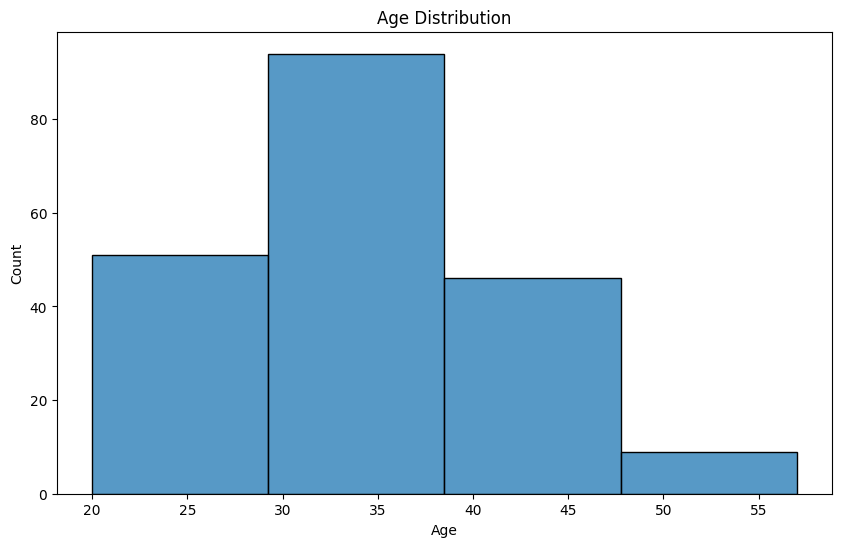

In [12]:
#Histogram
plt.figure(figsize=(10,6))
sns.histplot(x="Age",data=df,bins=4)
plt.title("Age Distribution")
plt.show()

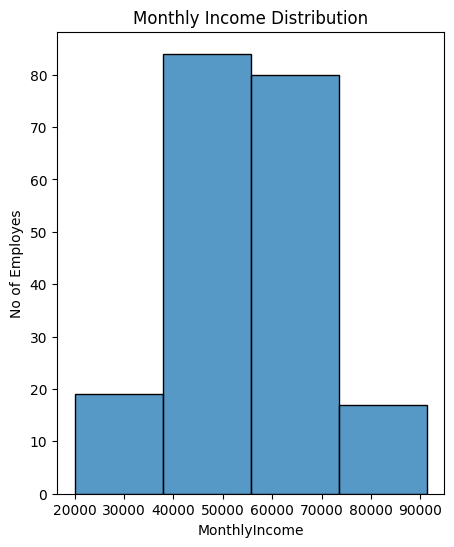

In [13]:
#Histogram
plt.figure(figsize=(5,6))
sns.histplot(x="MonthlyIncome",data=df,bins=4)
plt.title("Monthly Income Distribution")
plt.ylabel("No of Employes")
plt.show()

In [14]:
#Bivarient Analaysis

#1. Which city tier gives the highest avg monthly revenue
#2. Do males and  females spend differenthly
#3. How does Monthly Revenue changes with vsiists per month
#4. How does tenure Month relates with monthly
#5. How Age group is related wih visists per month





In [15]:
df.head()

,CustomerID,Age,Gender,CityTier,MonthlyIncome,TenureMonths,VisitsPerMonth,AvgOrderValue,MonthlyRevenue
0,1,39,Female,3,60700.0,23,4,830.30,3146.81
1,2,34,Female,1,44300.0,55,11,1853.62,20440.22
2,3,40,Female,1,48100.0,12,3,1794.74,4958.03
3,4,47,Female,3,65000.0,20,1,1687.47,1648.49
4,5,33,Male,1,48900.0,5,4,1526.80,6092.12


In [16]:
#1.
avg_revenue=df.groupby("CityTier")["MonthlyRevenue"].mean().reset_index()
print(round(avg_revenue,2))

   CityTier  MonthlyRevenue
0         1         8420.35
1         2         7717.74
2         3         9013.82


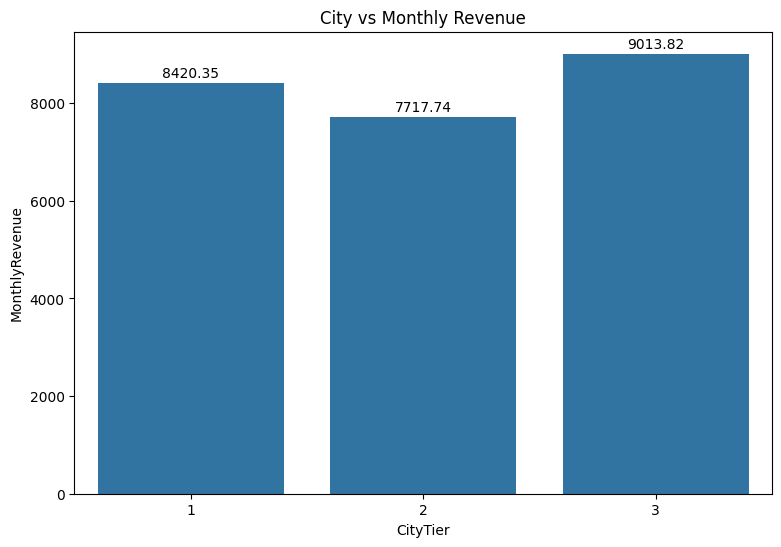

In [17]:
plt.figure(figsize=(9,6))
a=sns.barplot(x="CityTier",y="MonthlyRevenue",data=avg_revenue)
for container in a.containers:
  a.bar_label(container,fmt="%.2f",padding=2)
plt.title("City vs Monthly Revenue")
plt.show()


In [18]:
#2. Do males and female spend differently
avg_revenue=df.groupby("Gender")["MonthlyRevenue"].mean().reset_index()
print(round(avg_revenue,2))

   Gender  MonthlyRevenue
0  Female         8579.97
1    Male         8110.24


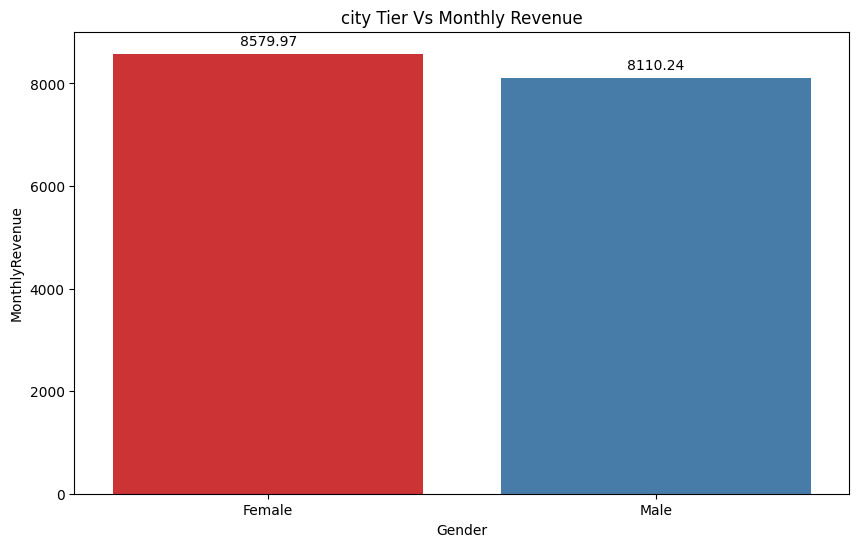

In [19]:
plt.figure(figsize=(10,6))
a=sns.barplot(x="Gender",y="MonthlyRevenue",data=avg_revenue,hue="Gender",palette="Set1",legend=False)
for container in a.containers:
  a.bar_label(container,fmt="%.2f",padding=4)
plt.title("city Tier Vs Monthly Revenue")
plt.show()

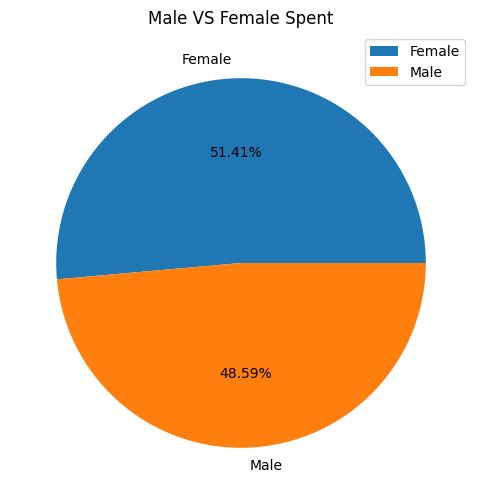

In [20]:
gender_count=df.groupby("Gender")["MonthlyRevenue"].mean()
plt.figure(figsize=(8,6))
plt.pie(gender_count,labels=gender_count.index,autopct="%1.2f%%")
plt.title("Male VS Female Spent")
plt.legend()
plt.show()

In [21]:
correlation=df[["MonthlyRevenue","VisitsPerMonth"]].corr()
print(correlation)

                MonthlyRevenue  VisitsPerMonth
MonthlyRevenue        1.000000        0.837128
VisitsPerMonth        0.837128        1.000000


In [22]:
correlation_tenure_mr=df[["MonthlyRevenue","TenureMonths","Age","VisitsPerMonth"]].corr()
print(correlation)

                MonthlyRevenue  VisitsPerMonth
MonthlyRevenue        1.000000        0.837128
VisitsPerMonth        0.837128        1.000000


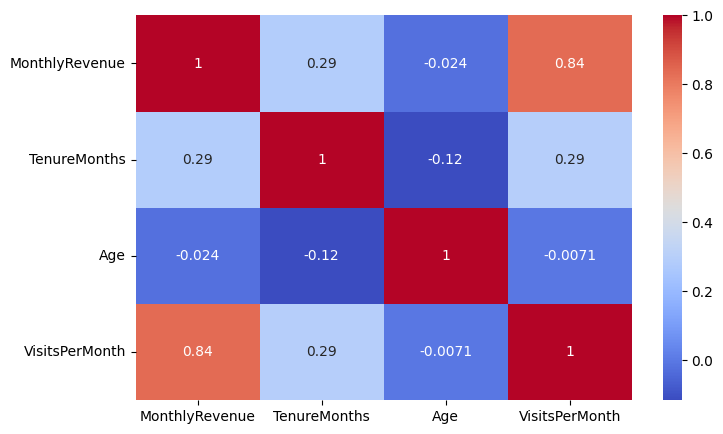

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(correlation_tenure_mr,cmap="coolwarm",annot=True)
plt.show()